In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle





In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from rdkit import RDLogger

#rdkit warn off
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Skin Sensitization\dataset\train_set_skin_sensitization_features_rdkitcdk.sdf')
# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

# Modred handling calc
if 'Modred_Descriptor' in train_df.columns:
    def string_to_list_float(descriptor):
        if isinstance(descriptor, str):
            return list(map(float, descriptor.strip('[]').split(',')))
        return descriptor
    train_df['Modred_Descriptor'] = train_df['Modred_Descriptor'].apply(string_to_list_float)

print("Train DataFrame:")
print(train_df.head())
print(train_df.keys())


Train DataFrame:
                                       Compound name Outcome LLNA class RowID  \
0               2-Methyl-5-nitrobenzenesulfonic acid       1              278   
1  2-{4-chloro-3-[(4-ethoxyphenyl)methyl]phenyl}-...       1              295   
2                                            Eugenol       1       Weak    56   
3      3-Aminomethyl-3,5,5- trimethylcyclohexylamine       1     Strong   309   
4                                 2-Methylresorcinol       1              280   

                                  Morgan_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [3]:
train_df

,Compound name,Outcome,LLNA class,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,2-Methyl-5-nitrobenzenesulfonic acid,1,,278,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.2618503396950841, -0.2395050914825213, 0.29...",278,Cc1ccc([N+](=O)[O-])cc1S(=O)(=O)O,217.004493324,...,1.0,0.0,3.0,0.5,2.0,0.0,105.89,4.807354922057604,0.7339999999999998,0.1428571428571428
1,2-{4-chloro-3-[(4-ethoxyphenyl)methyl]phenyl}-...,1,,295,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.05548471118588, 1.0726857698606813, 1.08843...",295,CCOc1ccc(Cc2cc(C3(OC)OC(CO)C(O)C(O)C3O)ccc2Cl)cc1,438.14453088399995,...,4.0,2.0,3.0,0.4666666666666667,7.0,0.0,108.61,6.0,2.571,0.4545454545454545
2,Eugenol,1,Weak,56,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.40585377622973534, -0.3327703846875663, -0...",56,C=CCc1ccc(O)c(OC)c1,164.083729624,...,1.0,3.0,3.0,0.4285714285714285,3.0,0.0,29.46,4.584962500721156,2.556000000000001,0.2
3,"3-Aminomethyl-3,5,5- trimethylcyclohexylamine",1,Strong,309,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8271726095254701, -0.7058315575077464, -0....",309,CC1(C)CC(N)CC(C)(CN)C1,170.17829870399999,...,2.0,0.0,2.0,0.4,1.0,0.0,52.04,4.584962500721156,1.658,1.0
4,2-Methylresorcinol,1,,280,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5610765042860587, -0.47849740532044915, -0...",280,Cc1c(O)cccc1O,124.052429496,...,2.0,0.0,0.0,0.25,0.0,0.0,40.46,4.169925001442312,1.436,0.1428571428571428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,"2-[3,3-bis(3-tert-butyl-4-hydroxyphenyl)butano...",0,,721,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.6320767585868783, 2.9839766049168466, 2.508...",721,CC(C)(C)c1cc(C(C)(CC(=O)OCCOC(=O)CC(C)(c2ccc(O...,794.475769072,...,4.0,4.0,12.0,0.4736842105263157,17.0,3.0,133.52,6.930737337562887,13.290000000000004,0.48
790,Pigment Violet 29,0,,930,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5344303244743063, 2.0280073495651356, 2.218...",930,O=C1NC(=O)c2ccc3c4ccc5c6c(ccc(c7ccc1c2c73)c64)...,390.0640568,...,2.0,0.0,0.0,0.4545454545454545,0.0,0.0,92.34,6.169925001442312,4.352,0.0
791,"[(1R,4aR,4bS,10aR)-1,4a-dimethyl-7-propan-2-yl...",1,,473,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4723778025395882, -0.2686504956090979, -0....",473,CC(C)C1CCC2C(CCC3C(C)(CO)CCCC23C)C1,292.276615772,...,1.0,3.0,3.0,0.5,2.0,1.0,20.23,5.523561956057013,8.159999999999998,1.0
792,"4-fluoro-4-methyl-2-[(2,2,2-trifluoro-1-{4'-me...",0,,795,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.8140776202583173, 1.1497591718842952, 1.540...",795,CC(C)(F)CC(NC(c1ccc(-c2ccc(S(C)(=O)=O)cc2)cc1)...,461.1283920959999,...,2.0,5.0,8.0,0.4666666666666667,9.0,0.0,91.85,6.0,3.519999999999999,0.3809523809523809


In [4]:
train_df= train_df.sort_values(['Outcome'], ascending=True)
train_df['RowID'] = train_df.index
train_df.head(100)

,Compound name,Outcome,LLNA class,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
793,"2-[2-chloro-4-[3-chloro-4-[1-[(4-chloro-2,5-di...",0,,793,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[3.2885566560808166, 3.487868258482993, 2.8993...",717,COc1cc(NC(=O)/C(=N/Nc2ccc(-c3ccc(N/N=C(\C(C)=O...,816.103572704,...,4.0,4.0,5.0,0.4814814814814814,17.0,3.0,178.03999999999996,6.832890014164742,12.134000000000002,0.1666666666666666
643,"2,6-Dimethylaniline",0,,643,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7828232586522349, -0.6183953451280166, -0....",661,Cc1cccc(C)c1N,121.08914935199999,...,1.0,0.0,0.0,0.25,0.0,0.0,26.02,4.169925001442312,1.657,0.25
329,"3,3-bis(4-hydroxyphenyl)-2-benzofuran-1-one",0,,329,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.7250546710377631, 1.0195763667855864, 1.079...",749,O=C1OC(c2ccc(O)cc2)(c2ccc(O)cc2)c2ccccc21,318.089208928,...,2.0,0.0,0.0,0.5,2.0,0.0,66.76,5.754887502163469,4.376000000000001,0.05
644,2-(4-chloro-2-nitrophenyl)diazenyl-N-(2-methox...,0,,644,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.2883188032703652, 1.2417291137948252, 1.049...",676,COc1ccccc1NC(=O)/C(=N/Nc1ccc(Cl)cc1[N+](=O)[O-...,390.07309726,...,2.0,4.0,5.0,0.4615384615384615,8.0,1.0,122.93,5.807354922057604,6.3210000000000015,0.1176470588235294
327,3-Hydroxy-4-methoxybenzaldehyde,0,Non-sensitizer,327,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.25063104817341203, -0.2744795764344132, -0...",760,COc1ccc(C=O)cc1O,152.047344116,...,1.0,0.0,2.0,0.4285714285714285,2.0,0.0,46.53,4.459431618637298,0.959,0.125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286,4-Methylbenzenesulfonamide,0,,286,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.42556459884006204, -0.6844582611482569, -0...",786,Cc1ccc(S(N)(=O)=O)cc1,171.035399528,...,1.0,0.0,3.0,0.5,1.0,0.0,68.53999999999999,4.459431618637298,0.918,0.1428571428571428
285,2-[2-chloro-4-[3-chloro-4-[1-[(2-methoxyphenyl...,0,,285,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.716395277531054, 2.950297471259469, 2.42462...",715,COc1ccccc1NC(=O)/C(=N/Nc1ccc(-c2ccc(N/N=C(\C(C...,688.16038804,...,4.0,4.0,5.0,0.48,15.0,3.0,159.57999999999998,6.672425341971496,11.060000000000002,0.1176470588235294
280,2-Butoxyethyl acetate,0,Non-sensitizer,280,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4502031271029706, -0.5717626985254941, -0....",525,CCCCOCCOC(C)=O,160.109944372,...,0.0,4.0,10.0,0.4444444444444444,7.0,0.0,35.53,4.321928094887363,1.4010000000000002,0.875
279,oxepan-2-one,0,,279,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.660862543750838, -0.6766861533811698, -0.6...",977,O=C1CCCCCO1,114.06807956,...,0.0,0.0,0.0,0.25,0.0,0.0,26.3,4.0,0.9349999999999998,0.8333333333333334


Classes                          :  ['0' '1']
Number of cpds in each class     :  [380 414]
Total number of cpds             :  794


{'0': 0, '1': 1}

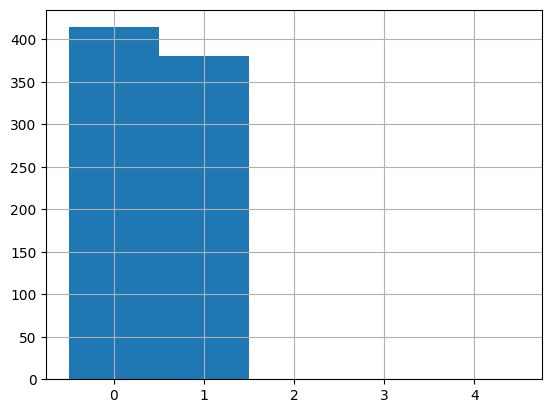

In [5]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(train_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( train_df['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S =train_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [6]:
y= np.int32((S))
def string_to_list(descriptor):
    if isinstance(descriptor, str):
        return list(map(float, descriptor.strip('[]').split(',')))
    return descriptor

# Apply the function to the 'Modred_Descriptor' column
train_df['Modred_Descriptor'] = train_df['Modred_Descriptor'].apply(string_to_list)

# Convert 'Modred_Descriptor' column to a NumPy array
x = np.array(train_df['Modred_Descriptor'].tolist())

# Print the shape of the resulting array
print(f"x.shape: {x.shape}")
print(x)

x.shape: (794, 545)
[[ 3.28855666  3.48786826  2.89930131 ...  2.96304469  2.92081327
   3.24717267]
 [-0.78282326 -0.61839535 -0.62853517 ... -0.63166806 -0.59186239
  -0.76487879]
 [ 0.72505467  1.01957637  1.07957435 ...  0.79382148  0.92089574
   0.46833375]
 ...
 [ 0.28156116  0.2501377   0.23821254 ... -0.04287891 -0.05342306
   0.16688179]
 [ 2.34380598  1.10701258  1.38420534 ...  1.10371051  0.93371573
   1.12056616]
 [-0.52781449 -0.44352292 -0.54149775 ... -0.04287891 -0.11752298
   0.06822479]]


In [7]:
#Random Forest
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# parameter
paramgrid = {
    "n_estimators": [120],  
    "max_features": [
        int(np.sqrt(x.shape[1])),     
        int(x.shape[1] / 6)           
    ],
    "max_depth": [6, 8, 10],         
    "min_samples_leaf": [3, 5, 8],    
    "min_samples_split": [10, 20]     
}

# Define the cross-validator as before
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

kappa_scorer = make_scorer(cohen_kappa_score)

model_rf_modred = GridSearchCV(estimator=RandomForestClassifier(class_weight='balanced'),
                     param_grid=paramgrid,
                     scoring=kappa_scorer,
                     cv=cv,
                     verbose=1,
                     n_jobs=-1) 

# Fit the model
model_rf_modred.fit(x, y)
best_model_rf_modred = model_rf_modred.best_estimator_


print("Best Params:", model_rf_modred.best_params_)
print("Best Score :", model_rf_modred.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'max_depth': 8, 'max_features': 23, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 120}
Best Score : 0.4034137584103014


In [8]:
#Random Forest
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_rf_modred.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_rf_modred.predict(X_test)
    y_proba = best_model_rf_modred.predict_proba(X_test)[:, 1]  
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[50 33]
 [23 53]]
Confusion Matrix for Fold 2:
[[63 20]
 [17 59]]
Confusion Matrix for Fold 3:
[[55 28]
 [23 53]]
Confusion Matrix for Fold 4:
[[57 26]
 [30 46]]
Confusion Matrix for Fold 5:
[[59 23]
 [21 55]]
Overall CV Accuracy: 0.6927314704243293
Overall CV AUC: 0.7658818844054008
Overall CV Precision: 0.6722905188953663
Overall CV Recall (Sensitivity): 0.7
Overall CV F1 Score: 0.6853355763622184
Overall CV Specificity: 0.6860711137231854
Overall CV PPV (Positive Predictive Value): 0.6722905188953663
Overall CV NPV (Negative Predictive Value): 0.7140464251541246
Overall CV CCR (Correct Classification Rate): 0.6930355568615927


In [9]:
# SVM 
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid 
paramgrid = {
     "C": [0.1,1,1.5,2], #Regularization
     "kernel": ['linear','rbf'],  # Type of the kernel
     "gamma": ['scale', 'auto']  # Kernel coefficient

}

# 5-fold stratified shuffle split
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Cohen’s Kappa 
kappa_scorer = make_scorer(
    cohen_kappa_score,
    weights="quadratic"
)

# GridSearchCV
model_svm_modred = GridSearchCV(
    estimator=SVC(
        probability=True,
        class_weight="balanced",
        random_state=24
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    refit=True,
    verbose=1,
    n_jobs=-1
)

# Fit model
model_svm_modred.fit(x, y)

# Best model
best_model_svm_modred = model_svm_modred.best_estimator_

print("Best Params:", model_svm_modred.best_params_)
print("Best Score :", model_svm_modred.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'C': 1.5, 'gamma': 'auto', 'kernel': 'rbf'}
Best Score : 0.41075293334436197


In [10]:
#SVM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_svm_modred.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_svm_modred.predict(X_test)
    y_proba = best_model_svm_modred.predict_proba(X_test)[:, 1]  
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[54 29]
 [22 54]]
Confusion Matrix for Fold 2:
[[59 24]
 [12 64]]
Confusion Matrix for Fold 3:
[[53 30]
 [15 61]]
Confusion Matrix for Fold 4:
[[60 23]
 [22 54]]
Confusion Matrix for Fold 5:
[[57 25]
 [17 59]]
Overall CV Accuracy: 0.7241939336040123
Overall CV AUC: 0.7820301746137309
Overall CV Precision: 0.6903768921841211
Overall CV Recall (Sensitivity): 0.7684210526315789
Overall CV F1 Score: 0.7267308725987564
Overall CV Specificity: 0.6836027034969145
Overall CV PPV (Positive Predictive Value): 0.6903768921841211
Overall CV NPV (Negative Predictive Value): 0.7645803166663508
Overall CV CCR (Correct Classification Rate): 0.7260118780642466


In [11]:
# XGB 
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

paramgrid = {
     "max_depth": [3,7],
     "n_estimators": [100,300],
     "learning_rate": [0.05,0.2],  # Step size shrinkage used to prevent overfitting
}

# 5-fold stratified CV
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Cohen's Kappa 
kappa_scorer = make_scorer(cohen_kappa_score)

model_xgb_modred = GridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=24,
        n_jobs=-1
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1
)

model_xgb_modred.fit(x, y)
best_model_xgb_modred = model_xgb_modred.best_estimator_

print("Best Params:", model_xgb_modred.best_params_)
print("Best Score :", model_xgb_modred.best_score_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300}
Best Score : 0.47012348472995213


In [12]:
#XGB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_xgb_modred.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_xgb_modred.predict(X_test)
    y_proba = best_model_xgb_modred.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[60 23]
 [25 51]]
Confusion Matrix for Fold 2:
[[62 21]
 [21 55]]
Confusion Matrix for Fold 3:
[[60 23]
 [18 58]]
Confusion Matrix for Fold 4:
[[60 23]
 [29 47]]
Confusion Matrix for Fold 5:
[[66 16]
 [26 50]]
Overall CV Accuracy: 0.7166467637926917
Overall CV AUC: 0.785245603724268
Overall CV Precision: 0.7115854222871766
Overall CV Recall (Sensitivity): 0.6868421052631579
Overall CV F1 Score: 0.6981197364524123
Overall CV Specificity: 0.7441081398765796
Overall CV PPV (Positive Predictive Value): 0.7115854222871766
Overall CV NPV (Negative Predictive Value): 0.7227299363395574
Overall CV CCR (Correct Classification Rate): 0.7154751225698687


In [13]:
#Neural Network 
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid
paramgrid_nn = {
    "hidden_layer_sizes": [(100,), (128, 64)],  
    "activation": ['relu'],             
    "solver": ['adam'],              
    "alpha": [0.0001]                          
}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_nn_modred = GridSearchCV(
    estimator=MLPClassifier(max_iter=700, random_state=42),
    param_grid=paramgrid_nn,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

# Fit the model
model_nn_modred.fit(x, y)
best_model_nn_modred = model_nn_modred.best_estimator_

print("Best Params:", model_nn_modred.best_params_)
print("Best Score :", model_nn_modred.best_score_)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best Params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'solver': 'adam'}
Best Score : 0.4082354470766453


In [14]:
#Neural Network NN
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model
    best_model_nn_modred.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_nn_modred.predict(X_test)
    y_proba = best_model_nn_modred.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[62 21]
 [26 50]]
Confusion Matrix for Fold 2:
[[55 28]
 [17 59]]
Confusion Matrix for Fold 3:
[[52 31]
 [18 58]]
Confusion Matrix for Fold 4:
[[56 27]
 [25 51]]
Confusion Matrix for Fold 5:
[[61 21]
 [26 50]]
Overall CV Accuracy: 0.6977390335164397
Overall CV AUC: 0.7465023122013082
Overall CV Precision: 0.6784286341740325
Overall CV Recall (Sensitivity): 0.7052631578947368
Overall CV F1 Score: 0.6899677126846278
Overall CV Specificity: 0.6909491625036732
Overall CV PPV (Positive Predictive Value): 0.6784286341740325
Overall CV NPV (Negative Predictive Value): 0.7207597872540401
Overall CV CCR (Correct Classification Rate): 0.6981061601992051


In [15]:
# LGBM 
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid 
paramgrid = {
    "n_estimators": [200,230],
    "learning_rate": [0.005,0.1],
    "max_depth": [12,15],
    "num_leaves": [26],
    "min_child_samples": [20],
    "feature_fraction": [0.7],
    "bagging_fraction": [0.7],
    "bagging_freq": [1]
}

# Cross-validator 
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Scoring function
kappa_scorer = make_scorer(
    cohen_kappa_score,
    weights='quadratic'
)

# GridSearchCV
model_lgbm_modred = GridSearchCV(
    estimator=LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        verbosity=-1,
        force_row_wise=True,
        random_state=24
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

# fit model
model_lgbm_modred.fit(x, y)
best_model_lgbm_modred = model_lgbm_modred.best_estimator_

print("Best Params:", model_lgbm_modred.best_params_)
print("Best Score :", model_lgbm_modred.best_score_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'bagging_fraction': 0.7, 'bagging_freq': 1, 'feature_fraction': 0.7, 'learning_rate': 0.1, 'max_depth': 15, 'min_child_samples': 20, 'n_estimators': 230, 'num_leaves': 26}
Best Score : 0.4449239918658202


In [16]:
# LGBM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

# Cross-validation setup
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Inisialisasi list metrik
accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model 
    best_model_lgbm_modred.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_lgbm_modred.predict(X_test)
    y_proba = best_model_lgbm_modred.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[59 24]
 [27 49]]
Confusion Matrix for Fold 2:
[[64 19]
 [19 57]]
Confusion Matrix for Fold 3:
[[58 25]
 [20 56]]
Confusion Matrix for Fold 4:
[[60 23]
 [23 53]]
Confusion Matrix for Fold 5:
[[64 18]
 [25 51]]
Overall CV Accuracy: 0.7191545259135419
Overall CV AUC: 0.7891110011290348
Overall CV Precision: 0.7098179514477854
Overall CV Recall (Sensitivity): 0.7
Overall CV F1 Score: 0.7043821227796827
Overall CV Specificity: 0.7368204525418749
Overall CV PPV (Positive Predictive Value): 0.7098179514477854
Overall CV NPV (Negative Predictive Value): 0.7285426564855229
Overall CV CCR (Correct Classification Rate): 0.7184102262709375


In [17]:
import joblib

base_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Skin Sensitization\model\fingerprint descriptor model"

joblib.dump(
    best_model_rf_modred,
    fr"{base_path}\Model_Skin_sens_RF_modred.pkl",
    compress=9
)

joblib.dump(
    best_model_svm_modred,
    fr"{base_path}\Model_Skin_sens_SVM_modred.pkl",
    compress=9
)

joblib.dump(
    best_model_xgb_modred,
    fr"{base_path}\Model_Skin_sens_XGB_modred.pkl",
    compress=9
)

joblib.dump(
    best_model_nn_modred,
    fr"{base_path}\Model_Skin_sens_NN_modred.pkl",
    compress=9
)

joblib.dump(
    best_model_lgbm_modred,
    fr"{base_path}\Model_Skin_sens_LGBM_modred.pkl",
    compress=9
)


['C:\\Users\\User\\Documents\\KULIAH TELKOM S1\\SKRIPSI\\UJI COBA QSAR - PRIBADI\\Skin Sensitization\\model\\fingerprint descriptor model\\Model_Skin_sens_LGBM_modred.pkl']